# **Atividade LSTM - Multiplas saídas**

Atividade LSTM - Multiplas Saídas
Nesta atividade, redes neurais do tipo Long Short-Term Memory (LSTM) serão empregadas para determinar os valores de **alta** e **baixa** das ações  da Apple Inc. Para tanto, serão considerados os dados referentes aos valores de abertura, alta e baixa das ações, além do volume de negociações diário da companhia.

A base de dados utilizada neste exemplo será obtida por meio da API yFinance e conterá informações das ações da Apple Inc. (AAPL) referentes ao período compreendido entre 1º de janeiro de 2023 e 31 de dezembro de 2023


# **Base de dados Apple Inc. (AAPL)**


Dados históricos de preços (abertura, fechamento, alta, baixa, volume) para diversas ações da Apple Inc.

* Close	 ->  Preço de fechamento  
* High	- >  Preço na  alta
* Low   ->  Preço  na baixa
* Open  -> Preço de abertura
* Volume - >  Volume de ações negociadas

# **1 Carregar e explorar  os dados**

In [1]:
import yfinance as yf

# Baixar dados da Apple (2010-2023)
data = yf.download('AAPL', start='2023-01-01', end='2023-12-31')


/tmp/ipython-input-388035594.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2023-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


In [2]:
#Verificando a existência de dados nulos
data.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [3]:
print(data.head(10))

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  123.330650  129.079567  122.443165  128.468194  112117500
2023-01-04  124.602715  126.870731  123.340517  125.125343   89113600
2023-01-05  123.281349  125.993105  123.024970  125.362006   80962700
2023-01-06  127.817368  128.478048  123.153152  124.257579   87754700
2023-01-09  128.339996  131.554669  128.083618  128.655553   70790800
2023-01-10  128.911911  129.434539  126.338208  128.448446   63896200
2023-01-11  131.633560  131.653271  128.645700  129.424706   69458900
2023-01-12  131.554657  132.392827  129.612053  132.018122   71379600
2023-01-13  132.885864  133.043643  129.828986  130.193835   57809700
2023-01-17  134.049500  135.380716  132.264673  132.954936   63646600


In [4]:
import matplotlib.pyplot as plt

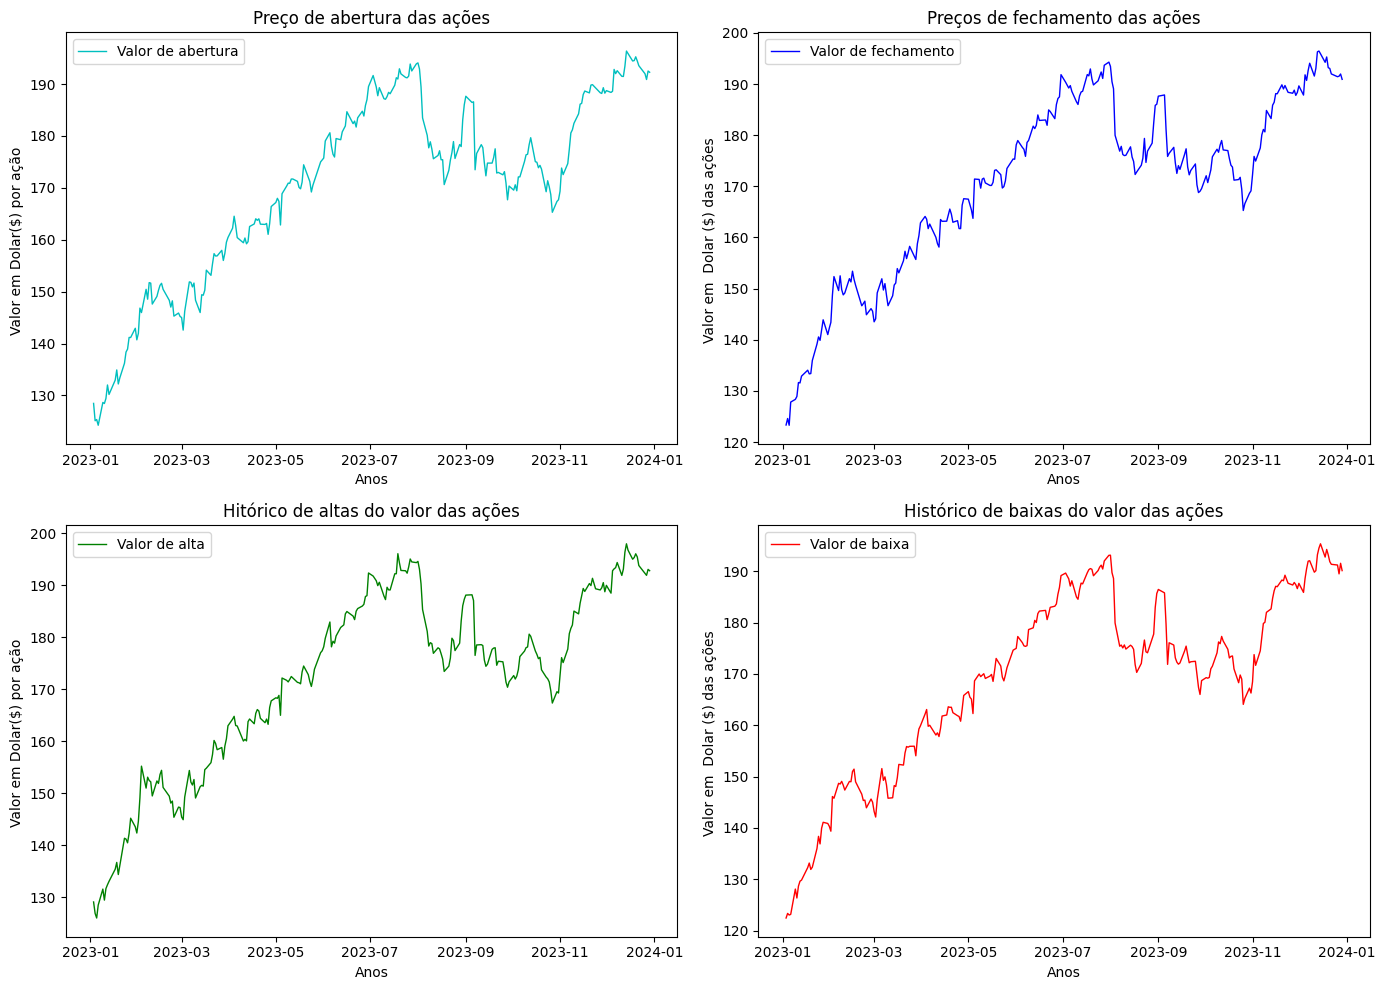

In [5]:
# Gráfico de dispersão para os targets
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

#Abertura
ax1.plot(data.index, data.Open, 'c-', linewidth=1, label='Valor de abertura')
ax1.set_xlabel('Anos')
ax1.set_ylabel('Valor em Dolar($) por ação ')
ax1.set_title('Preço de abertura das ações')
ax1.legend( loc ='best')

#Fechamento
ax2.plot(data.index, data.Close, 'b-', linewidth=1, label='Valor de fechamento')
ax2.set_xlabel('Anos')
ax2.set_ylabel('Valor em  Dolar ($) das ações ')
ax2.set_title('Preços de fechamento das ações')
ax2.legend(loc ='best')



#Alta
ax3.plot(data.index, data.High, 'g-', linewidth=1, label='Valor de alta')
ax3.set_xlabel('Anos')
ax3.set_ylabel('Valor em Dolar($) por ação ')
ax3.set_title('Hitórico de altas do valor das ações')
ax3.legend(loc ='best')
#Baixa
ax4.plot(data.index, data.Low, 'r-', linewidth=1, label='Valor de baixa')
ax4.set_xlabel('Anos')
ax4.set_ylabel('Valor em  Dolar ($) das ações ')
ax4.set_title('Histórico de baixas do valor das ações')
ax4.legend(loc='best')

plt.tight_layout()
plt.show()

**2 TensorFlow - Explanação de alguns paramêtros**

**Parâmentros**

 *  **Dense:** representa uma camada neural totalmente conectada (Fully Connected Layer),onde cada neurônio é conectado a todos os neurônios da camada anterior.É uma das camadas mais fundamentais em redes neurais artificiais.
 * **O Dropout:** é uma camada de regularização usada em redes neurais para evitar overfitting (sobreajuste). Ele funciona "desligando" aleatoriamente uma fração dos neurônios durante o treinamento, forçando a rede a aprender representações mais robustas e generalizáveis.
 * **Callbacks:** são ferramentas que permitem monitorar e intervir no processo de treinamento de modelos de deep learning.Eles são acionados em eventos específicos (ex: fim de uma época) e ajudam a melhorar a eficiência do treinamento, evitar overfitting e salvar os melhores modelos.
 * **EarlyStopping:**  Interromper o treinamento antecipadamente se o modelo parar de melhorar.
 * **ReduceLROnPlateau:** Reduz a taxa de aprendizado (learning rate) quando o modelo para de melhorar.
 * **ModelCheckpoint:**  Salvar o modelo (ou seus pesos) periodicamente durante o treinamento.

In [6]:
# TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau, ModelCheckpoint


# **3  Particionando a base de dados**
* X_treinamento, y_treinamento
* X_teste, y_teste


## **3.1 Construindo a base de treinamento (X_treinamento, y_treinamento)**


In [8]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

In [9]:
#Serão utilizados aproximadamente 80% dos dados para teinamento e 20% dos dados para teste
#250*0.80= 200, portanto aproximadamente 116

nn_base_treinamento = 200
base_treinamento =data.iloc[0:nn_base_treinamento, [0, 3] ].values

In [10]:
base_treinamento.shape

(200, 2)

In [11]:
base_treinamento

array([[123.33065033, 128.46819392],
       [124.60271454, 125.12534264],
       [123.28134918, 125.36200611],
       [127.81736755, 124.25757881],
       [128.33999634, 128.65555332],
       [128.91191101, 128.44844618],
       [131.63356018, 129.42470644],
       [131.55465698, 132.01812185],
       [132.88586426, 130.19383505],
       [134.04949951, 132.95493556],
       [133.32962036, 134.91723045],
       [133.38879395, 132.21534096],
       [135.95265198, 133.39867444],
       [139.14756775, 136.1991446 ],
       [140.5478363 , 138.35870861],
       [139.88716125, 138.93064979],
       [141.95794678, 141.17892493],
       [143.90055847, 141.16909143],
       [141.0112915 , 142.9440403 ],
       [142.28334045, 140.71545633],
       [143.40748596, 141.96779873],
       [148.72254944, 146.82923769],
       [152.35134888, 145.97132678],
       [149.61987305, 150.44820253],
       [152.49928284, 148.54505516],
       [149.80723572, 151.73998448],
       [148.77185059, 151.64138491],
 

In [12]:
#Definindo o normalizador
normalizador =MinMaxScaler(feature_range=(0,1))
normalizado_previsores  = MinMaxScaler(feature_range=(0,1))

In [13]:
#Normalizando a base de treinamento ()
base_treinamento_normalizada =normalizador.fit_transform(base_treinamento)

In [14]:
#Normalizando a base de treinamento (Alvos)
base_treinamento_alvo= data.iloc[0:nn_base_treinamento, [1, 2] ].values
base_treinamento_alvo_norm  =normalizado_previsores.fit_transform(base_treinamento_alvo)

### 3.1.1 **Adequando a base de treinamento a entreda LSTM**

In [15]:
#intervalo utilizado para relizar as previsões futuras é de 12 meses
intervalo_previsao =12

In [16]:
X=[] #previsores norm
yh_norm =[] #preço norm (high)
yl_norm =[] #preço norm (Low)

for i in range(intervalo_previsao,nn_base_treinamento):
  X.append(base_treinamento_normalizada[i-intervalo_previsao:i,:])
  yh_norm.append(base_treinamento_alvo_norm[i,0])
  yl_norm.append(base_treinamento_alvo_norm[i,1])


# Ao final deste loop X conterá em cada uma de suas entradas,
# uma lista do 12 registros.

In [17]:
#Convertendo X e y de Listas para Arrays
X = np.array(X)
yh_norm =np.array(yh_norm)
yl_norm =np.array(yl_norm)


In [18]:
X.shape

(188, 12, 2)

In [19]:
yh_norm.shape,yl_norm.shape

((188,), (188,))

In [20]:
y_treino_norm = np.column_stack( (yh_norm,yl_norm))

In [21]:
y_treino_norm.shape

(188, 2)

## **3.2 Construindo a base de teste (X_teste, y_teste)**



In [22]:
# A base de teste será composta pelos elementos que estão
# apos a posição limite da base de treino, ou seja, após a posição 116
base_teste = data.iloc[nn_base_treinamento:,[0,3]].values

In [23]:
base_teste

array([[173.7580719 , 174.33243269],
       [171.20306396, 173.60948564],
       [171.32191467, 169.25219112],
       [171.75764465, 171.37142823],
       [169.44035339, 170.21278626],
       [165.27116394, 168.71740366],
       [166.58827209, 165.29098147],
       [168.63819885, 167.38052859],
       [169.11354065, 167.70731642],
       [172.28250122, 169.34130886],
       [175.84757996, 173.81746191],
       [174.93650818, 172.5498964 ],
       [177.49147034, 174.66912431],
       [180.05638123, 177.44197431],
       [181.1159668 , 180.58121144],
       [180.640625  , 181.18529302],
       [184.83509827, 182.42550626],
       [183.24855042, 184.25999144],
       [185.86639404, 186.12420583],
       [186.43159485, 186.2729496 ],
       [188.11734009, 187.97851603],
       [188.09751892, 188.65281519],
       [189.8427124 , 188.29581153],
       [189.03953552, 189.80307544],
       [189.70387268, 189.88236938],
       [188.37513733, 189.26757547],
       [188.19664001, 188.32555346],
 

In [24]:
base_teste.shape

(50, 2)

## **Construindo a base de entrada dos teste**

In [25]:
#base contem todos os dados
base_completa = data

In [26]:
len(base_completa), len(base_teste)

(250, 50)

In [27]:
X_entradas = base_completa.iloc[len(base_completa) - len(base_teste) - intervalo_previsao:, [0,3]].values
y_entradas = base_completa.iloc[len(base_completa) - len(base_teste) - intervalo_previsao:, [1,2]].values

In [28]:
X_entradas.shape, y_entradas.shape

((62, 2), (62, 2))

In [29]:
##Normalizando os dados de entrada
X_entradas_normalizadas = normalizador.fit_transform(X_entradas)
y_entradas_normalizadas = normalizado_previsores.fit_transform(y_entradas)


In [30]:
X_teste = []
y_teste_h =[]
y_teste_l =[]
nn_entradas =len(X_entradas )
for i in range(intervalo_previsao, nn_entradas):
  #print(i)
  X_teste.append(X_entradas_normalizadas[i - intervalo_previsao:i, :])
  y_teste_h.append(y_entradas_normalizadas[i - intervalo_previsao, 0])
  y_teste_l.append(y_entradas_normalizadas[i - intervalo_previsao, 1])



# Ao final deste loop X_teste conterá em cada uma de suas entradas,
# uma lista do 12 registros.


In [31]:
X_teste_array =np.array(X_teste)

In [32]:
y_teste_array =np.column_stack((y_teste_h,y_teste_l ))

In [33]:
X_teste_array.shape

(50, 12, 2)

In [34]:
y_teste_array.shape

(50, 2)

In [35]:
y_teste_array

array([[0.15101993, 0.16302868],
       [0.16977676, 0.16777737],
       [0.20987639, 0.2219092 ],
       [0.29201628, 0.23773726],
       [0.32629469, 0.32067616],
       [0.34796116, 0.38873623],
       [0.35216597, 0.37765755],
       [0.43268755, 0.4232411 ],
       [0.41942949, 0.39475164],
       [0.32726448, 0.34315137],
       [0.30592149, 0.28902029],
       [0.27875646, 0.29883273],
       [0.2871655 , 0.30136645],
       [0.20890554, 0.22064247],
       [0.1633089 , 0.13485504],
       [0.15231381, 0.1829722 ],
       [0.1325876 , 0.15764751],
       [0.07825865, 0.        ],
       [0.        , 0.03672134],
       [0.07146806, 0.10129985],
       [0.06273612, 0.07059305],
       [0.17042321, 0.14086958],
       [0.28522442, 0.3099129 ],
       [0.2541804 , 0.24311921],
       [0.33858273, 0.33365504],
       [0.4359224 , 0.42102621],
       [0.46858311, 0.50396397],
       [0.49024972, 0.51092827],
       [0.57742774, 0.57303069],
       [0.55994207, 0.59458573],
       [0.

# **4.  Construindo a Rede Neural LSTM**

In [36]:
X.shape[1]

12

## **4.1 - Definindo a estrutura da rede regressora**

In [37]:
regressor = Sequential()

regressor.add(LSTM(units = 100, return_sequences=True, input_shape = (X.shape[1], 2)))
#regressor.add(Dropout(0.1))

regressor.add(LSTM(units = 50, return_sequences=True))
#regressor.add(Dropout(0.1))

regressor.add(LSTM(units = 50, return_sequences=True))
#regressor.add(Dropout(0.1))

regressor.add(LSTM(units = 50))
#regressor.add(Dropout(0.1))

regressor.add(Dense(units = 2, activation = 'linear'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [39]:
regressor.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 100)        │        41,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 12, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,902 (437.12 KB)

 Trainable params: 111,902 (437.12 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
regressor.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['mean_absolute_error'])

* **optimizer** =  Algoritmo que ajusta os pesos da rede neural
   * **Adam:** Adaptive Moment Estimation (um dos otimizadores mais populares)
   * **Características do Adam:**
    *  Adapta a taxa de aprendizado automaticamente
    *  Lida bem com dados esparsos
    *  Boa performance na maioria dos problemas
    * Poucos hiperparâmetros para ajusta

| **Característica**       | **Loss (MSE)**                     | **Metrics (MAE)**               |
|--------------------------|------------------------------------|---------------------------------|
| **Função principal**     | Usada para treinar                | Usada para monitorar           |
| **Propósito**            | Guia os ajustes dos pesos         | Mostra performance             |
| **Requisito**            | Deve ser diferenciável            | Pode ser qualquer métrica      |
| **Comportamento do erro** | Penaliza erros grandes            | Erro linear                    |

## **4.2 Definindo os parâmtros do callback**

In [41]:
#EarlyStopping:Interromper o treinamento antecipadamente se o modelo parar de melhorar.
es =EarlyStopping(monitor='loss', min_delta=1e-10,patience=10, verbose=True)

In [42]:
#EarlyStopping:Interromper o treinamento antecipadamente se o modelo parar de melhorar.
rlr =ReduceLROnPlateau(monitor='loss', factor=0.2,patience=5, verbose=True)

In [43]:
#ModelCheckpoint:Salvar o modelo (ou seus pesos) periodicamente durante o treinamento
mcp = ModelCheckpoint(filepath='pesos.keras', monitor='loss', save_best_only=True, verbose=True)

## 4.3 **Realizando o treinamento da Rede LSTM**

In [45]:
regressor.fit(X, y_treino_norm, epochs = 100, batch_size = 32,callbacks=[es,rlr,mcp])

Epoch 1/100
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0048 - mean_absolute_error: 0.0553
Epoch 1: loss did not improve from 0.00499
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0049 - mean_absolute_error: 0.0559 - learning_rate: 1.0240e-10
Epoch 2/100
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0055 - mean_absolute_error: 0.0611
Epoch 2: loss did not improve from 0.00499
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0054 - mean_absolute_error: 0.0599 - learning_rate: 1.0240e-10
Epoch 3/100
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0047 - mean_absolute_error: 0.0547
Epoch 3: loss did not improve from 0.00499
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0048 - mean_absolute_error: 0.0554 - learning_rate: 1.0240e-10
Epoch 4/100
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0047 - mean_absolute_error: 0.0555
Epoch 4: loss did not improve from 0.00499
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0048 - mean_absolute_error: 0.0559 - learning_rate: 1.0240e-10
Epoc

## **5. Realizando as previsões**

In [46]:
previsores_normalizados =regressor.predict(X_teste_array)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step


In [47]:
previsores_reais =normalizado_previsores.inverse_transform(previsores_normalizados)

In [48]:
y_teste =normalizado_previsores.inverse_transform(y_teste_array)

In [49]:
previsores_reais[:,0]

array([178.10204, 178.84807, 179.54277, 179.93211, 180.04782, 179.7798 ,
       179.3528 , 178.68166, 177.71   , 176.68408, 175.84923, 175.09637,
       174.50801, 173.98929, 173.80084, 173.99538, 174.24217, 174.92747,
       176.19846, 177.78531, 179.32321, 180.99141, 182.50882, 183.68126,
       185.10202, 186.33061, 187.31943, 188.13477, 188.98485, 189.5345 ,
       190.09529, 190.40698, 190.67166, 190.7495 , 190.80153, 190.78828,
       190.78577, 190.78964, 190.95638, 191.23878, 191.55856, 191.95183,
       192.42258, 192.85204, 193.43022, 193.80759, 194.06873, 194.26544,
       194.3518 , 194.58679], dtype=float32)

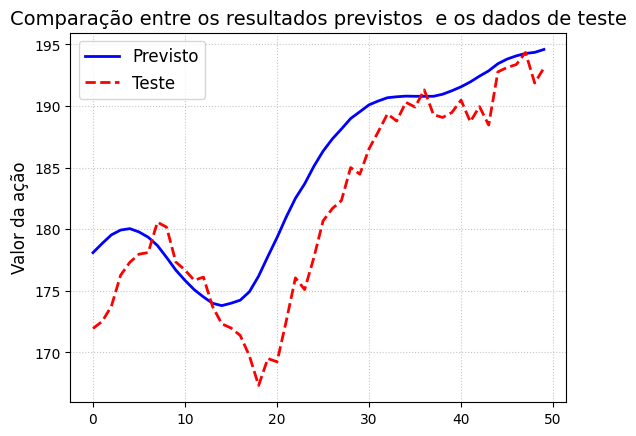

In [50]:
# Plotando as duas curvas

plt.plot( previsores_reais[:,0], 'b-', linewidth=2, label='Previsto')      # Curva azul
plt.plot( y_teste[:,0], 'r--', linewidth=2, label='Teste')  # Curva vermelha tracejada

# Personalizando o gráfico
plt.title('Comparação entre os resultados previstos  e os dados de teste', fontsize=14)
plt.ylabel('Valor da ação', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)  # Grade pontilhada
plt.legend(fontsize=12, loc='best')  # Legenda



# Mostrando o gráfico
plt.show()

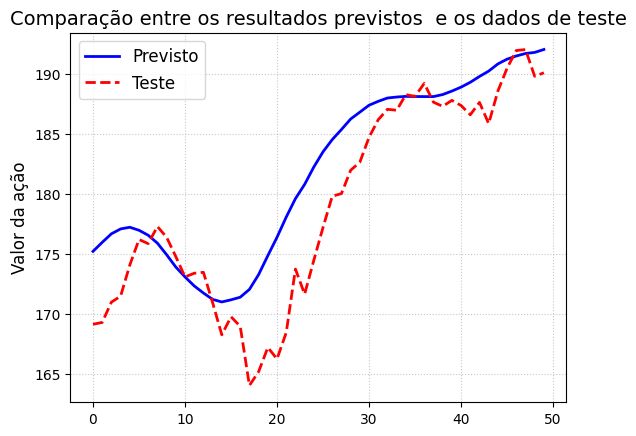

In [51]:
# Plotando as duas curvas

plt.plot( previsores_reais[:,1], 'b-', linewidth=2, label='Previsto')      # Curva azul
plt.plot( y_teste[:,1], 'r--', linewidth=2, label='Teste')  # Curva vermelha tracejada

# Personalizando o gráfico
plt.title('Comparação entre os resultados previstos  e os dados de teste', fontsize=14)
plt.ylabel('Valor da ação', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)  # Grade pontilhada
plt.legend(fontsize=12, loc='best')  # Legenda



# Mostrando o gráfico
plt.show()